Sales Prediction Challenge


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# 1. Define the Problem 🎯
We want to predict the sales, so it's regression.

# 1. 2. Collect Data 🗂️

we load the dataset into a pandas DataFrame to inspect its structure and understand the available features.

In [2]:
df = pd.read_csv("../data/sales.csv")

df.head()

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


# 3. Exploratory Data Analysis (EDA) 🔍

Before training any model, we analyse and understand the dataset.

We will review:

- Number of rows and columns (features)
- Data types
- Missing values, invalid objects, etc
- Basic statistics

In [ ]:
df.shape

(640840, 10)

In [4]:
# Display all column names
df.columns

Index(['Unnamed: 0', 'store_ID', 'day_of_week', 'date', 'nb_customers_on_day',
       'open', 'promotion', 'state_holiday', 'school_holiday', 'sales'],
      dtype='str')

In [11]:
# Dataset dimensions
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Rows: 640840
Columns: 10


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


In [5]:
# Check data types and non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Unnamed: 0           640840 non-null  int64
 1   store_ID             640840 non-null  int64
 2   day_of_week          640840 non-null  int64
 3   date                 640840 non-null  str  
 4   nb_customers_on_day  640840 non-null  int64
 5   open                 640840 non-null  int64
 6   promotion            640840 non-null  int64
 7   state_holiday        640840 non-null  str  
 8   school_holiday       640840 non-null  int64
 9   sales                640840 non-null  int64
dtypes: int64(8), str(2)
memory usage: 48.9 MB


In [6]:
# Check missing values per column
df.isna().sum()

Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64

### Key Takeaways

- No missing values were detected.
- No imputation is required.

In [7]:
# Summary statistics for numeric columns
df.describe()

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


### Key Takeaways

- Customer counts vary considerably.
- No obviously impossible values were observed.

In [8]:
# Check number of unique values per column
df.nunique()

Unnamed: 0             640840
store_ID                 1115
day_of_week                 7
date                      942
nb_customers_on_day      3886
open                        2
promotion                   2
state_holiday               4
school_holiday              2
sales                   20129
dtype: int64

In [9]:
# Check the target variable distribution
df["sales"].describe()

count    640840.000000
mean       5777.469011
std        3851.338083
min           0.000000
25%        3731.000000
50%        5746.000000
75%        7860.000000
max       41551.000000
Name: sales, dtype: float64

##  Histograms

Matplotlib is building the font cache; this may take a moment.


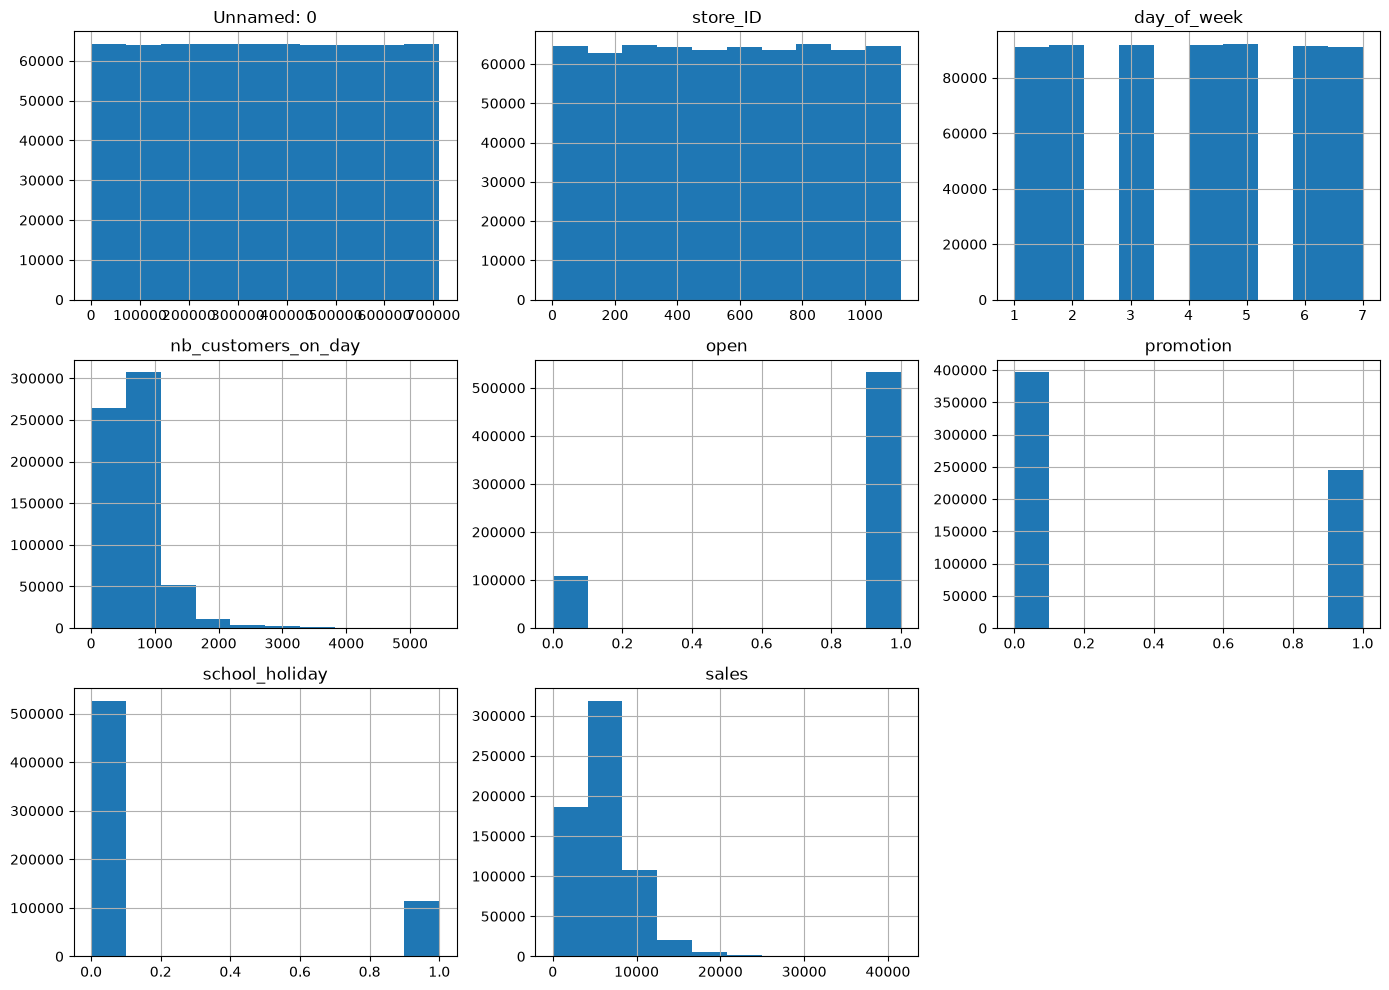

In [12]:
import matplotlib.pyplot as plt

df.hist(figsize=(14,10))
plt.tight_layout()
plt.show()

## Boxplots (Outlier Detection)

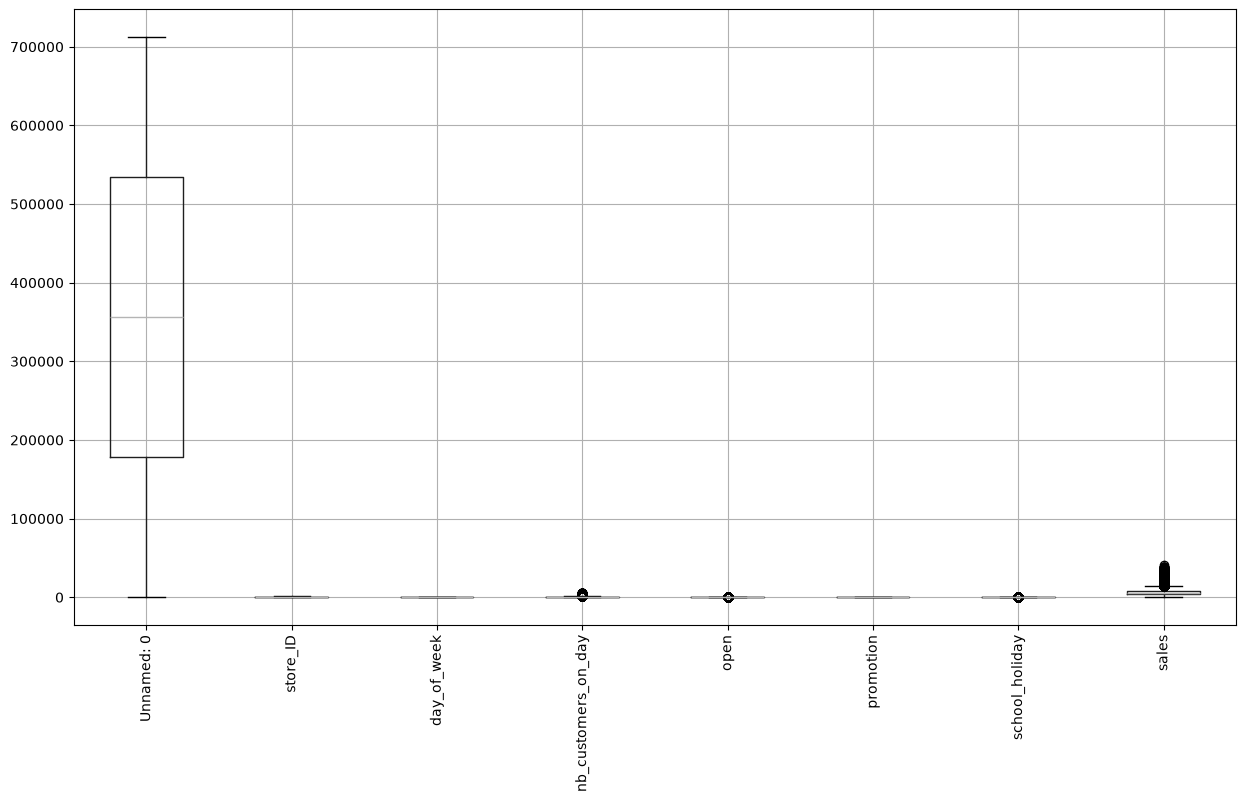

In [13]:
numeric_cols = df.select_dtypes(include="number").columns

plt.figure(figsize=(15,8))
df[numeric_cols].boxplot(rot=90)
plt.show()

## Categorical Features

In [14]:
categorical_cols = df.select_dtypes(include="object").columns

categorical_cols

/var/folders/pd/lzb5ddwn6bgf72j6mrnpgw2h0000gn/T/ipykernel_60062/2424776929.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


Index(['date', 'state_holiday'], dtype='str')

In [15]:
df["state_holiday"].value_counts()

state_holiday
0    621160
a     12842
b      4214
c      2624
Name: count, dtype: int64

In [16]:
df["school_holiday"].value_counts()

school_holiday
0    526468
1    114372
Name: count, dtype: int64

In [17]:
df["day_of_week"].value_counts()

day_of_week
5    92138
4    91972
2    91686
3    91651
6    91347
7    91075
1    90971
Name: count, dtype: int64

## Correlation Heatmap

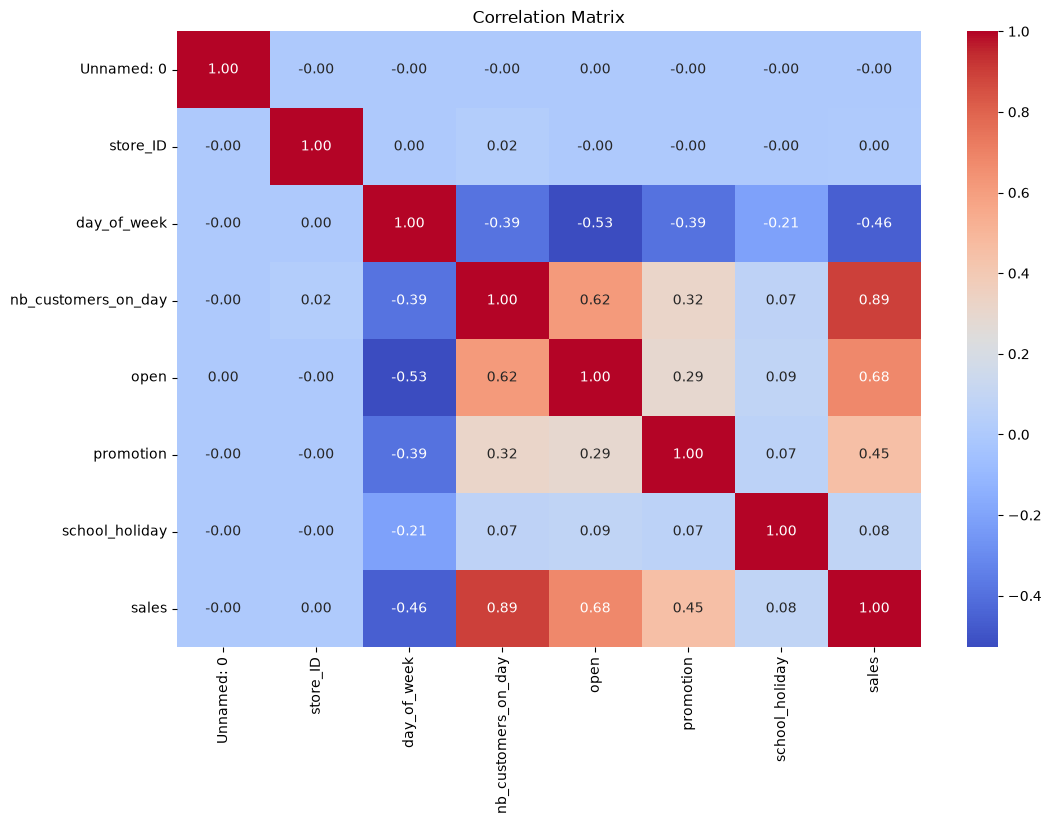

In [18]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### Key Takeaways

- The dataset shows no signs of severe multicollinearity between the predictor variables.
- The strongest positive correlation with the target variable (`sales`) is the number of customers on a given day, suggesting customer traffic is the strongest predictor of sales.
- Whether the store is open (`open`) also has a strong positive relationship with sales, which is expected since closed stores generate little or no sales.
- Promotions have a moderate positive correlation with sales, indicating that promotions tend to increase sales but are not the only driving factor.
- School holidays show almost no linear relationship with sales (r ≈ 0.08).
- `day_of_week` has a moderate negative correlation with sales (r ≈ -0.46), suggesting that sales vary depending on the day of the week.
- Store ID has virtually no correlation with sales, which is expected since it is an identifier rather than a meaningful feature.

## 4. Data Cleaning

Before splitting the data, we perform only simple cleaning steps that do not learn from the data.

For this dataset, we:

- Remove irrelevant index-like columns
- Convert the date column to datetime
- Extract useful date features
- Keep the original target variable `sales`

In [10]:
# Create a copy of the original dataset before cleaning
df_clean = df.copy()

# Convert the date column from object/string to datetime
df_clean["date"] = pd.to_datetime(df_clean["date"])

# Extract useful date-based features
df_clean["year"] = df_clean["date"].dt.year
df_clean["month"] = df_clean["date"].dt.month
df_clean["day"] = df_clean["date"].dt.day

# Remove columns that are not useful for model training
df_clean = df_clean.drop(columns=["Unnamed: 0", "date"])

# Preview the cleaned dataset
df_clean.head()

,store_ID,day_of_week,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales,year,month,day
0,366,4,517,1,0,0,0,4422,2013,4,18
1,394,6,694,1,0,0,0,8297,2015,4,11
2,807,4,970,1,1,0,0,9729,2013,8,29
3,802,2,473,1,1,0,0,6513,2013,5,28
4,726,4,1068,1,1,0,0,10882,2013,10,10


### Data Cleaning Observations

After exploring the dataset, we observed the following:

- The dataset contains both numerical and categorical features.
- The target variable is **sales**, making this a **regression** problem.
- The `date` column was converted to a datetime object, and new features (`year`, `month`, and `day`) were extracted to better represent temporal information.
- The original `date` column was removed after extracting its useful components.
- No obvious irrelevant columns remain, except the index-like column (`Unnamed: 0`), which was removed.
- The dataset will later be split into **70% training**, **15% validation**, and **15% testing** to prevent data leakage and allow proper model evaluation.

# 5. Data Splitting ✂️

we split the cleaned dataset to the following way:

- **Training set (70%)**: Used to train the machine learning models.
- **Validation set (15%)**: Used to compare models and tune hyperparameters.
- **Test set (15%)**: Reserved for the final evaluation and kept completely unseen during model development.

In [19]:
# Separate features (X) from the target variable (y)

X = df_clean.drop(columns=["sales"])
y = df_clean["sales"]

In [21]:
# First split:
# 70% Training
# 30% Validation & Test

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [ ]:
# Split the remaining 30% equally into: 
# 15% Validation 
# 15% Test 

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [23]:
print("Training set :", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set :", X_test.shape)

Training set : (448588, 10)
Validation set: (96126, 10)
Test set : (96126, 10)


In [24]:
print("Training")
print(y_train.describe())

print("\nValidation")
print(y_val.describe())

print("\nTest")
print(y_test.describe())

Training
count    448588.000000
mean       5775.192526
std        3852.932817
min           0.000000
25%        3727.000000
50%        5743.000000
75%        7860.000000
max       41551.000000
Name: sales, dtype: float64

Validation
count    96126.000000
mean      5778.225433
std       3852.089186
min          0.000000
25%       3732.000000
50%       5738.000000
75%       7853.000000
max      38367.000000
Name: sales, dtype: float64

Test
count    96126.000000
mean      5787.336184
std       3843.158741
min          0.000000
25%       3749.000000
50%       5770.000000
75%       7867.000000
max      38025.000000
Name: sales, dtype: float64
